In [10]:
!pip install transformers torchvision Pillow requests torch

In [11]:
import torch
import requests
from PIL import Image
from torchvision import models, transforms
import torch.nn as nn
from transformers import AutoProcessor, AutoModelForCausalLM
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [12]:

print("Loading ResNet model... 🧠")
resnet = models.resnet50(pretrained=True)
resnet.eval()
print("✅ ResNet loaded!")


print("Loading caption generator... 🤖")
processor = AutoProcessor.from_pretrained("microsoft/git-base-coco")
caption_model = AutoModelForCausalLM.from_pretrained("microsoft/git-base-coco")
print("✅ Caption model loaded!")

print("\n🎉 All models ready!")

Loading ResNet model... 🧠
✅ ResNet loaded!
Loading caption generator... 🤖


Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]

✅ Caption model loaded!

🎉 All models ready!


Please upload an image from your computer 👇


Saving Screenshot 2026-06-23 124837.png to Screenshot 2026-06-23 124837 (1).png


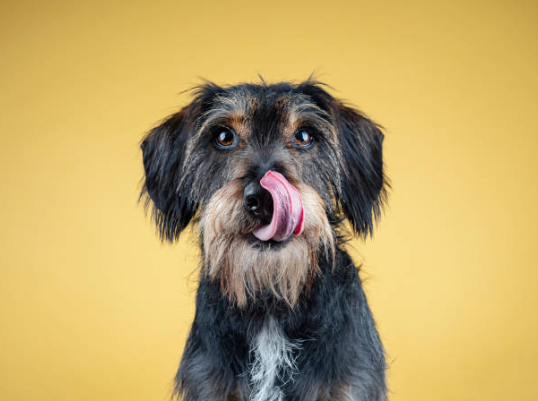

✅ Image loaded successfully!


In [13]:
from google.colab import files
from io import BytesIO


print("Please upload an image from your computer 👇")
uploaded = files.upload()


filename = list(uploaded.keys())[0]
image = Image.open(BytesIO(uploaded[filename])).convert("RGB")


display(image)
print("✅ Image loaded successfully!")

In [14]:
print("Generating caption... 🤖")

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    output = caption_model.generate(**inputs, max_new_tokens=50)

caption = processor.decode(output[0], skip_special_tokens=True)

print("\n" + "="*40)
print("🖼️  IMAGE CAPTION RESULT")
print("="*40)
print(f"📝 Caption: {caption}")
print("="*40)

Generating caption... 🤖

🖼️  IMAGE CAPTION RESULT
📝 Caption: portrait of a dog sticking its tongue out


In [15]:
from google.colab import files
from io import BytesIO

print("Upload 3 images from your computer 👇")
uploaded = files.upload()


Upload 3 images from your computer 👇


Saving Screenshot 2026-06-23 125235.png to Screenshot 2026-06-23 125235 (1).png
Saving Screenshot 2026-06-23 125317.png to Screenshot 2026-06-23 125317 (1).png
Saving Screenshot 2026-06-23 125449.png to Screenshot 2026-06-23 125449 (1).png


🖼️  IMAGE CAPTIONING RESULTS



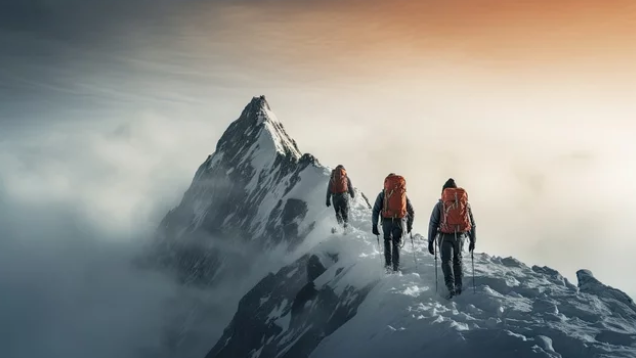

📝 Caption: the mountain range.
----------------------------------------



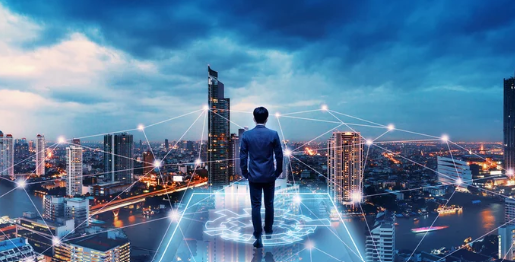

📝 Caption: a man standing on a platform in front of a city
----------------------------------------



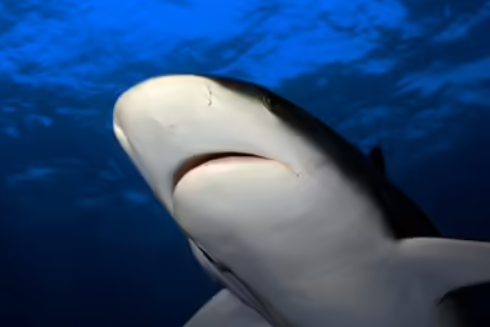

📝 Caption: a shark with a shark in the background
----------------------------------------



In [16]:
print("="*40)
print("🖼️  IMAGE CAPTIONING RESULTS")
print("="*40 + "\n")

for filename, data in uploaded.items():
    image = Image.open(BytesIO(data)).convert("RGB")
    display(image)

    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        output = caption_model.generate(**inputs, max_new_tokens=50)

    caption = processor.decode(output[0], skip_special_tokens=True)

    print(f"📝 Caption: {caption}")
    print("-"*40 + "\n")